In [1]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns


# Get Data

In [2]:
update_data = True

In [3]:
def get_data(table_name:str, update_data) -> [pd.DataFrame, pd.DataFrame]:
    if update_data:
        experimenter = PyExperimenter(experiment_configuration_file_path="conf/experiment_config.yml",
                                database_credential_file_path="conf/database_credentials.yml",
                                table_name=table_name)
        main_table = experimenter.get_table()
        log_table = experimenter.get_logtable("sh_iterations")

        main_table.to_csv(f"plain_data/{table_name}/table.csv", index=False)
        log_table.to_csv(f"plain_data/{table_name}/logtable.csv", index=False)
    else:
        main_table = pd.read_csv(f"plain_data/{table_name}/table.csv")
        log_table = pd.read_csv(f"plain_data/{table_name}/logtable.csv")

    return main_table, log_table


In [4]:
# reproducible table
sensitivity_study_table, sensitivity_study_logtable = get_data("priorbai_experiments_lcbench_kernels", update_data)
successive_halving_table, successive_halving_logtable = get_data("priorbai_experiments_lcbench_kernels", update_data)


2026-01-28 13:53:43,562  | py-experimenter - INFO     | Found 12 keyfields
2026-01-28 13:53:43,563  | py-experimenter - INFO     | Found 8 resultfields
2026-01-28 13:53:43,564  | py-experimenter - INFO     | Found 1 logtables
2026-01-28 13:53:43,565  | py-experimenter - INFO     | Found logtable all_results__sh_iterations
2026-01-28 13:53:43,565  | py-experimenter - WARNING  | No custom section defined in config
2026-01-28 13:53:43,566  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-01-28 13:53:43,629  | py-experimenter - INFO     | Initialized and connected to database
2026-01-28 13:53:44,172  | py-experimenter - INFO     | Found 12 keyfields
2026-01-28 13:53:44,172  | py-experimenter - INFO     | Found 8 resultfields
2026-01-28 13:53:44,173  | py-experimenter - INFO     | Found 1 logtables
2026-01-28 13:53:44,173  | py-experimenter - INFO     | Found logtable all_results__sh_iterations
2026-01-28 13:53:44,173  | py-experimenter - WARNING  | No custom sect

# Merge DataFrames

In [5]:
def merge_dataframes(main_df: pd.DataFrame, log_df: pd.DataFrame, ) -> pd.DataFrame:
    log_df = log_df.drop(columns=["ID"], errors='ignore')
    return main_df.merge(log_df, left_on="ID", right_on="experiment_id", how="left", suffixes=('_final', '_logtable'))

def subselect_max_budget_entries(merged_df: pd.DataFrame, num_arms:int) -> pd.DataFrame:
    idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']
    merged_df = merged_df[idx]
    merged_df = merged_df[merged_df["num_arms_final"] == num_arms]
    return merged_df

merged_sensitivity_study = merge_dataframes(sensitivity_study_table, sensitivity_study_logtable)

merged_sensitivity_study = subselect_max_budget_entries(merged_sensitivity_study, 256)

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_26528/615109824.py:6: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']


In [6]:
def rename_priors(df: pd.DataFrame) -> pd.DataFrame:
    rename_dict = {
        "uniform": "MF-PSH Uniform",
        "performance": "MF-PSH Performance",
        "rank": "MF-PSH Rank",
        "inverse_rank": "MF-PSH Inverse Rank",
        "indicator": "MF-PSH Indicator",
    }
    df['prior'] = df['prior'].map(rename_dict).fillna(df['prior'])
    return df

def final_plots(merged_df: pd.DataFrame, benchmark_name: str, fig_title: str, hue = None):
    # Standardizing font sizes
    TITLE_SIZE = 16
    LABEL_SIZE = 16
    TICK_SIZE = 14
    merged_df["Sigma"] = merged_df["sigma0"]


    def create_boxplot(sigma_data, x, y, ax):
        num_hues = sigma_data[hue].nunique() if (hue and hue in sigma_data.columns) else 0
        should_dodge = True if num_hues > 1 else False
        current_hue = hue if num_hues > 1 else None

        sns.boxplot(
            data=sigma_data, 
            x=x, 
            y=y, 
            hue=current_hue, 
            ax=ax, 
            palette="Set2",
            dodge=should_dodge
        )
        
        # --- Grid ---
        ax.grid(True, linestyle='--', alpha=0.6, axis='y') # Vertical lines usually clutter boxplots
        
        # --- Font & Tick Management ---
        ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
        
        # Fix: Explicitly set ticks before labels to avoid warnings
        ax.set_xticks(range(len(sigma_data[x].unique())))
        ax.set_xticklabels(
            sigma_data[x].unique(), 
            rotation=45, 
            ha='right', 
            fontsize=TICK_SIZE
        )
        
        if ax.get_legend():
            ax.get_legend().remove()

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

    # Left Plot
    create_boxplot(merged_df, "prior", "regret", ax[0])
    ax[0].set_title(f"Regret Distribution: {benchmark_name}", fontsize=TITLE_SIZE)
    ax[0].set_ylabel("Regret", fontsize=LABEL_SIZE)
    ax[0].set_xlabel(None,)

    # Right Plot
    create_boxplot(merged_df, "prior", "consumed_budget", ax[1])
    ax[1].set_title(f"Budget Consumption: {benchmark_name}", fontsize=TITLE_SIZE)
    ax[1].set_ylabel("Consumed Budget", fontsize=LABEL_SIZE)
    ax[1].set_xlabel(None,)

    # Global Legend
    if hue and merged_df[hue].nunique() > 1:
        handles, labels = ax[0].get_legend_handles_labels()
        fig.legend(
            handles, 
            labels, 
            loc='lower center', 
            bbox_to_anchor=(0.5, -0.05),
            ncol=3, 
            title=hue,
            fontsize=TICK_SIZE,
            title_fontsize=LABEL_SIZE,
            frameon=True
        )

    # Adjust layout to accommodate the rotated labels and legend
    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
    return fig

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_26528/1196584658.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  relevant_subset["Kernel"][relevant_subset["Kernel"] == "matern32"] = "Matern32"
/var/folders/3w/xg6_gz354xg5vfw2z

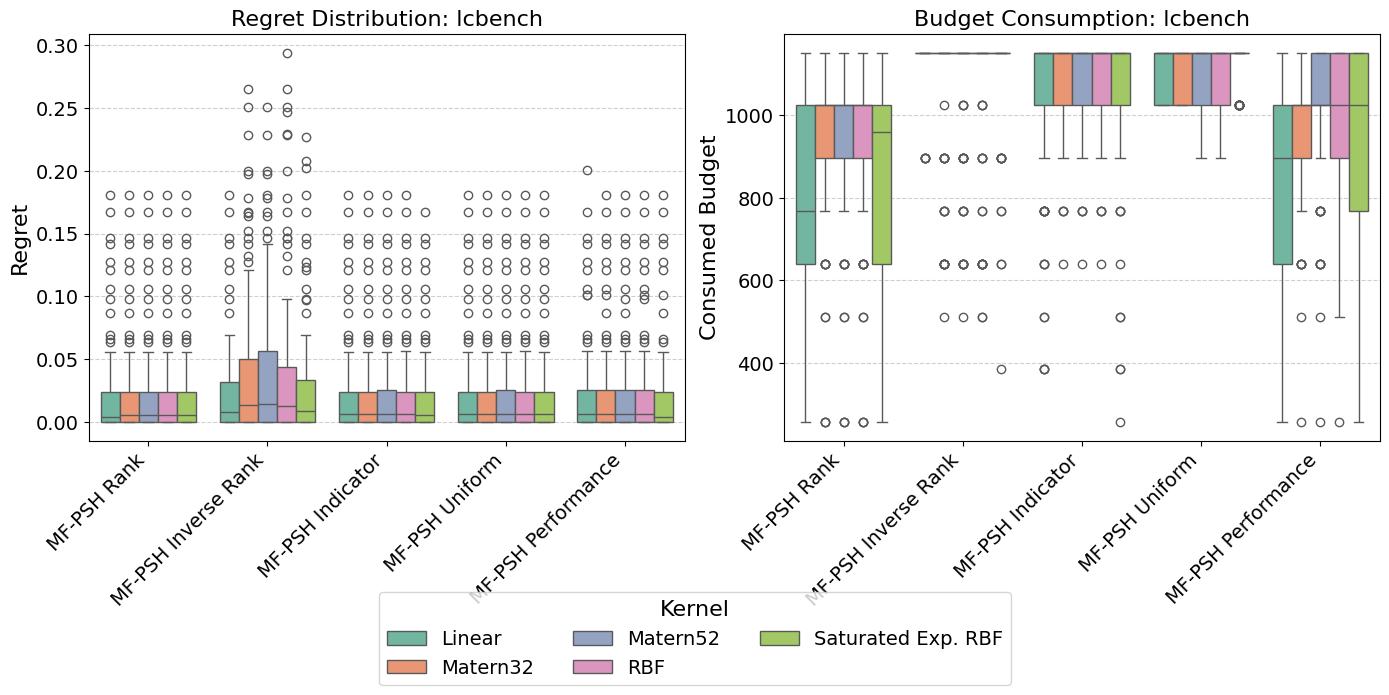

In [7]:
relevant_subset = merged_sensitivity_study[(merged_sensitivity_study["epsilon"] == 0.01) & (merged_sensitivity_study["sigma0"] == 0.0001) & (merged_sensitivity_study["delta"] == 0.01)]
relevant_subset["Kernel"] = relevant_subset["kernel"]
relevant_subset = relevant_subset.sort_values(by="Kernel")
relevant_subset["Kernel"][relevant_subset["Kernel"] == "matern32"] = "Matern32"
relevant_subset["Kernel"][relevant_subset["Kernel"] == "matern52"] = "Matern52"
relevant_subset["Kernel"][relevant_subset["Kernel"] == "rbf"] = "RBF"
relevant_subset["Kernel"][relevant_subset["Kernel"] == "satexp_rbf"] = "Saturated Exp. RBF"
relevant_subset["Kernel"][relevant_subset["Kernel"] == "linear"] = "Linear"
relevant_subset = rename_priors(relevant_subset)
final_plots(relevant_subset, "lcbench", "Sensitivity Study on LCBench Benchmark", hue="Kernel").savefig("plots/boxplots/kernel_comparison.pdf", bbox_inches='tight', dpi=300)